In [1]:
from typing import Literal
from datasets import Dataset, DatasetDict, load_dataset

class YambdaDataset:
    INTERACTIONS = frozenset([
        "likes", "listens", "multi_event", "dislikes", "unlikes", "undislikes"
    ])

    def __init__(
        self,
        dataset_type: Literal["flat", "sequential"] = "flat",
        dataset_size: Literal["50m", "500m", "5b"] = "50m"
    ):
        assert dataset_type in {"flat", "sequential"}
        assert dataset_size in {"50m", "500m", "5b"}
        self.dataset_type = dataset_type
        self.dataset_size = dataset_size

    def interaction(self, event_type: Literal[
        "likes", "listens", "multi_event", "dislikes", "unlikes", "undislikes"
    ]) -> Dataset:
        assert event_type in YambdaDataset.INTERACTIONS
        return self._download(f"{self.dataset_type}/{self.dataset_size}", event_type)

    def audio_embeddings(self) -> Dataset:
        return self._download("", "embeddings")

    def album_item_mapping(self) -> Dataset:
        return self._download("", "album_item_mapping")

    def artist_item_mapping(self) -> Dataset:
        return self._download("", "artist_item_mapping")

    @staticmethod
    def _download(data_dir: str, file: str) -> Dataset:
        data = load_dataset("yandex/yambda", data_dir=data_dir, data_files=f"{file}.parquet")
        # Returns DatasetDict; extracting the only split
        assert isinstance(data, DatasetDict)
        return data["train"]

/opt/homebrew/Cellar/jupyterlab/4.4.0/libexec/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display
from itertools import product

class MarkovChain:
    def __init__(self, name=None, data=None, struct=None, time_column=None, users_id_column=None):
        # struct, for example (действие, id_song) = (название поля, название поля айдишника)
        self.NAME = name # String
        self.data = data # pandas DataFrame
        self.struct = struct # tuple
        self.time_column = time_column # string
        self.users_id_column = users_id_column # string
        self.count_nodes = 0
        self.map_name_nodes: dict[int, str] = {}

        self.markov_chain: dict[str, dict[str, int]] = {}
        # {
        #     'id_node_1' : {2, 4, 6},
        #     'id_node_2': {1, 5, 70},
        #     ...
        #
        # }

    def preprocessing_data(self):
        if self.data is None:
            raise ValueError("Подан пустой датасет")

        self.data = self.data.sort_values(by=[self.users_id_column, self.time_column], ascending=True)

        if not self.struct:
            self.count_nodes = 0
            self.map_name_nodes = {}
            return

        unique_values = [self.data[col].unique() for col in self.struct]
        unique_counts = [len(values) for values in unique_values]
        self.count_nodes = np.prod(unique_counts)

        self.map_name_nodes = {}
        node_id = 0

        for combination in product(*unique_values):
            key = "_".join(str(val) for val in combination)
            self.map_name_nodes[node_id] = key
            node_id += 1

        return

    def build_markov_chain(self):
        if self.data is None or not self.struct:
            return

        START_NODE = "START"  # Добавляем специальную стартовую ноду
        self.map_name_nodes[-1] = START_NODE  # Используем -1 как ID для стартовой ноды
        self.count_nodes += 1

        self.markov_chain = {  # Инициализация цепи с учетом стартовой ноды
            f'id_node_{i}': {}
            for i in range(-1, self.count_nodes - 1)  # Включаем -1 (старт) и обычные ноды
        }

        self.node_name_to_id = {v: k for k, v in self.map_name_nodes.items()}  # Создаем обратный маппинг для быстрого поиска

        grouped = self.data.groupby(self.users_id_column)

        for user_id, user_data in grouped:
            prev_node = f'id_node_{-1}' # Всегда начинаем со стартовой ноды
            first_transition = True

            for _, row in user_data.iterrows():
                current_values = [str(row[col]) for col in self.struct]
                current_node_key = "_".join(current_values)
                current_node_id = self.node_name_to_id[current_node_key]

                if current_node_id in self.markov_chain[prev_node]:  # Добавляем переход
                    self.markov_chain[prev_node][f'id_node_{current_node_id}'] += 1
                else:
                    self.markov_chain[prev_node][f'id_node_{current_node_id}'] = 1

                prev_node = f'id_node_{current_node_id}'
                first_transition = False

        return


    def filter_by_time_range(self, start_time: int, end_time: int):
        """
        Удаляет строки из self.data, где время не входит в указанный интервал.
        Время указывается в секундах (целые числа).
        
        :param start_time: нижняя граница времени (включительно)
        :param end_time: верхняя граница времени (включительно)
        """
        if self.data is None or self.time_column not in self.data.columns:
            raise ValueError("Нет данных или отсутствует колонка времени.")
    
        before_count = len(self.data)
        self.data = self.data[
            (self.data[self.time_column] >= start_time) &
            (self.data[self.time_column] <= end_time)
        ]
        after_count = len(self.data)
    
        print(f"Отфильтровано по времени: оставлено {after_count} из {before_count} записей "
              f"(границы: {start_time} - {end_time})")
        

    def show_markov_chain(self, visualize=True, top_n=10):
        # Красивый табличный вывод
        print(f"\nМарковская цепь '{self.NAME}' (первые {top_n} переходов):")
        print("=" * 60)

        # Создаем DataFrame для красивого отображения
        transitions = []
        for source, targets in self.markov_chain.items():
            for target, count in targets.items():
                transitions.append({
                    'Из': source,
                    'В': target,
                    'Переходы': count,
                    'Вероятность': f"{count / sum(targets.values()):.2%}"
                })

        df = pd.DataFrame(transitions).sort_values('Переходы', ascending=False)
        display(df.head(top_n))

        # Визуализация графа
        if visualize:
            self._visualize_markov_chain()

    def _visualize_markov_chain(self):
        plt.figure(figsize=(14, 10))
        G = nx.DiGraph()

        # Добавляем узлы и ребра
        for source, targets in self.markov_chain.items():
            G.add_node(source)
            for target, weight in targets.items():
                G.add_edge(source, target, weight=weight)

        # Позиционирование узлов
        pos = nx.spring_layout(G, k=0.5, iterations=50)

        # Рисуем узлы
        nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue', alpha=0.9)

        # Рисуем ребра с толщиной по количеству переходов
        edge_width = [d['weight'] * 0.1 for u, v, d in G.edges(data=True)]
        nx.draw_networkx_edges(G, pos, width=edge_width, edge_color='gray', arrowsize=20)

        # Подписи узлов (только id без префикса)
        labels = {node: node.replace('id_node_', '') for node in G.nodes()}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold')

        # Подписи ребер с количеством переходов
        edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

        plt.title(f'Визуализация марковской цепи "{self.NAME}"', size=15)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

In [3]:
print("[1] Загружаем датасет...")
dataset = YambdaDataset("flat", "50m")
events = dataset.interaction("multi_event")

print("[2] Преобразуем в pandas DataFrame...")
df = events.to_pandas()

[1] Загружаем датасет...
[2] Преобразуем в pandas DataFrame...


In [4]:
df.head()

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,event_type
0,100,39420,8326270,0,100.0,170.0,listen
1,100,39420,1441281,0,100.0,105.0,listen
2,100,39625,286361,0,100.0,185.0,listen
3,100,40110,732449,0,100.0,240.0,listen
4,100,40360,3397170,0,46.0,130.0,listen


In [9]:
print("[3] Построение марковской цепи...")
mh = MarkovChain(
    name='Yambda_Markov',
    data=df,
    struct=('event_type', 'item_id'),
    time_column='timestamp',
    users_id_column='uid'
)
mh.filter_by_time_range(0, 100)
mh.preprocessing_data()
mh.build_markov_chain()
#mh.show_markov_chain(visualize=True, top_n=20)

[3] Построение марковской цепи...
Отфильтровано по времени: оставлено 45 из 47790449 записей (границы: 0 - 100)



Марковская цепь 'Yambda_Markov' (первые 20 переходов):


,Из,В,Переходы,Вероятность
0,id_node_-1,id_node_0,1,3.03%
23,id_node_-1,id_node_26,1,3.03%
25,id_node_-1,id_node_28,1,3.03%
26,id_node_-1,id_node_29,1,3.03%
27,id_node_-1,id_node_120,1,3.03%
28,id_node_-1,id_node_40,1,3.03%
29,id_node_-1,id_node_41,1,3.03%
30,id_node_-1,id_node_42,1,3.03%
31,id_node_-1,id_node_43,1,3.03%
32,id_node_-1,id_node_44,1,3.03%


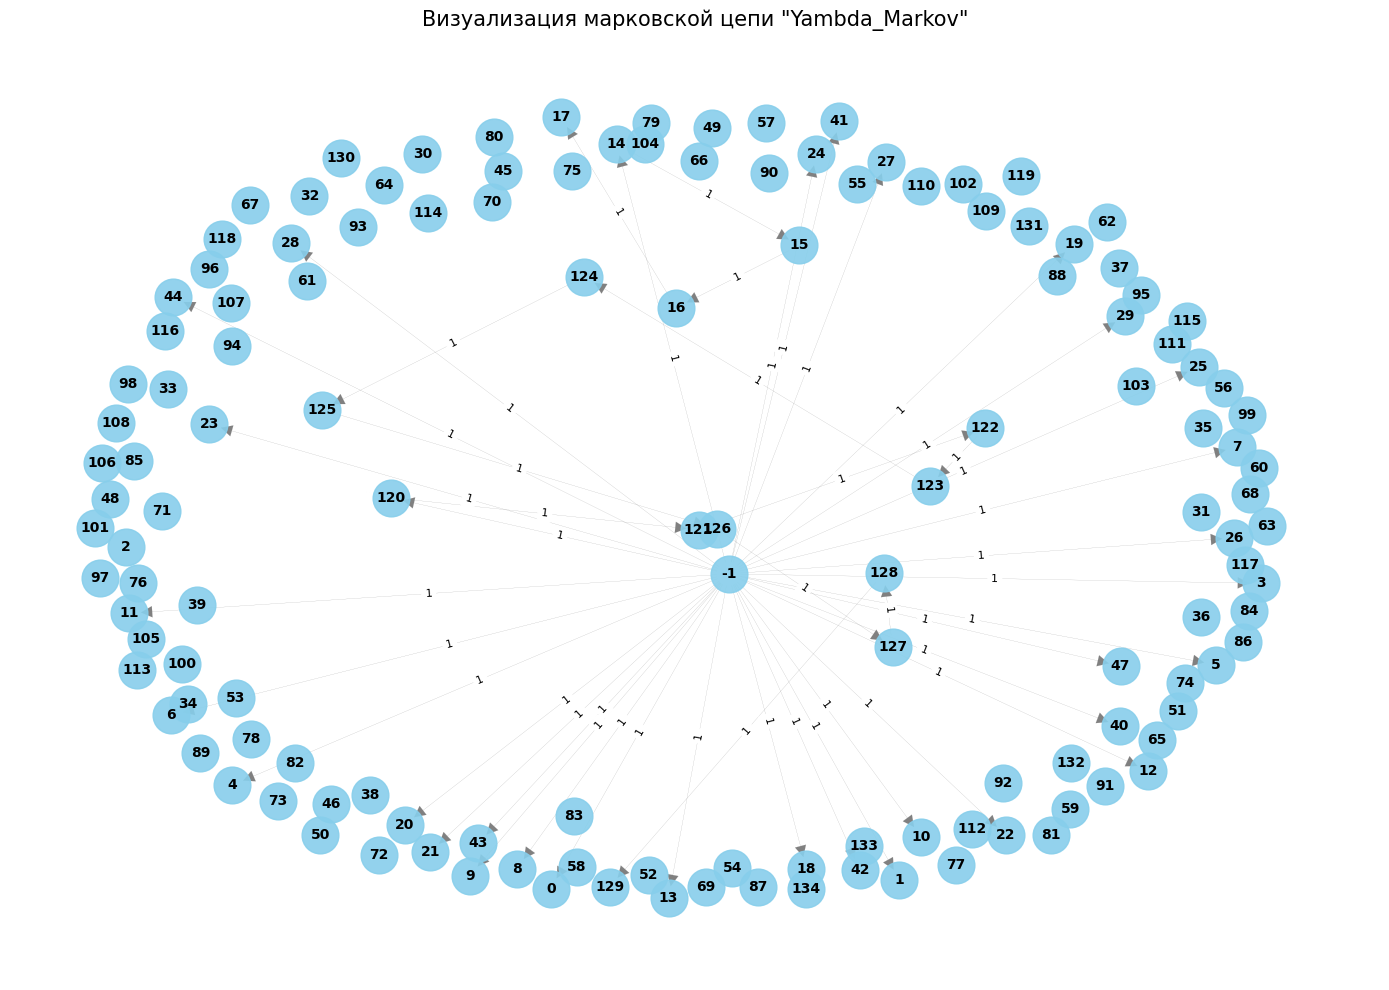

In [10]:
mh.show_markov_chain(visualize=True, top_n=20)